In [50]:
from sklearn.cluster import DBSCAN
import pandas as pd
from sklearn.preprocessing import StandardScaler,LabelEncoder


df = pd.read_csv('Mall_Customers.csv')

In [51]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [52]:
scaler = StandardScaler()
label = LabelEncoder()
df.drop('CustomerID',axis=1,inplace=True)
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = scaler.fit_transform(df[num_cols])
df['Gender'] = label.fit_transform(df['Gender'])

In [53]:
model = DBSCAN(eps=1.2,min_samples=5)

res = model.fit_predict(df)
df['res'] = res
core_points = df[df['res']!=-1]
outliers = df[df['res']==-1]
# model = DBSCAN()
# model.fit(df).labels_

In [54]:
core_points

,Gender,Age,Annual Income (k$),Spending Score (1-100),res
0,1,-1.424569,-1.738999,-0.434801,0
1,1,-1.281035,-1.738999,1.195704,0
2,0,-1.352802,-1.700830,-1.715913,0
3,0,-1.137502,-1.700830,1.040418,0
4,0,-0.563369,-1.662660,-0.395980,0
...,...,...,...,...,...
194,0,0.584899,2.268791,-1.327697,0
195,0,-0.276302,2.268791,1.118061,0
196,0,0.441365,2.497807,-0.861839,0
197,1,-0.491602,2.497807,0.923953,0


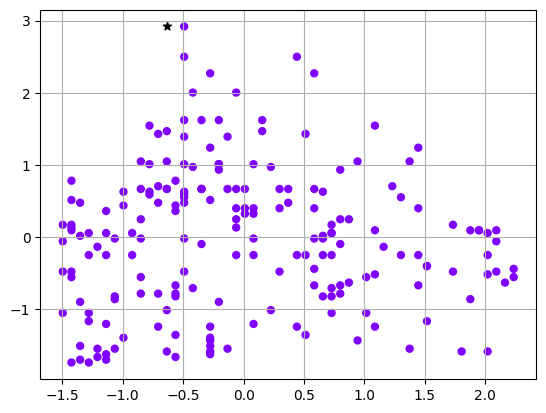

In [55]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(core_points.iloc[:,1],core_points.iloc[:,2],marker='.',c =core_points['res'],s=100,cmap='rainbow')
plt.scatter(outliers.iloc[:,1],outliers.iloc[:,2],marker='*',c='black')
plt.grid(True)
# core_points.iloc[:,1]

In [56]:
core_points.iloc[:,2]

0     -1.738999
1     -1.738999
2     -1.700830
3     -1.700830
4     -1.662660
         ...   
194    2.268791
195    2.268791
196    2.497807
197    2.497807
198    2.917671
Name: Annual Income (k$), Length: 199, dtype: float64

min_samples = D+1
min_samples = 4+1 => 5 or 6

eps - >


In [57]:
df = df.drop('res',axis=1)

In [58]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5

model = NearestNeighbors(n_neighbors=min_samples)
model.fit(df)
distance,index =model.kneighbors()

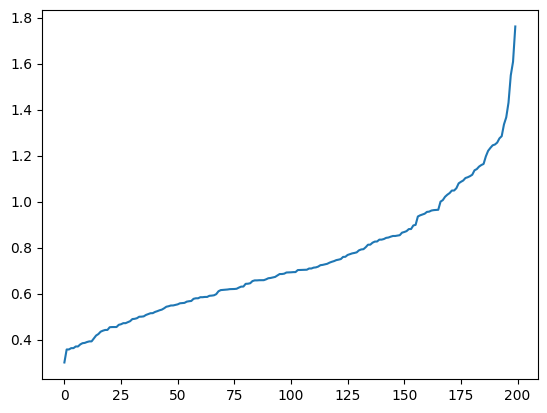

In [59]:
# distance
import numpy as np

sort = np.sort(model.kneighbors()[0][:,-1])
plt.plot(sort)

In [60]:
eps = 1.2 #or 1.25,1.3

In [61]:
model.kneighbors()[1]


array([[ 17,  20,   4,  61,  21],
       [ 15,  21,  17,  25,  33],
       [  6,   4,  16,  38,  14],
       [  5,  13,   9,  31,  29],
       [ 16,  28,  49,  48,  47],
       [  3,  13,  31,   9,  29],
       [ 22,  36,  14,  38,   2],
       [ 29,   3,  13,   5,  35],
       [ 10,  30,  32,  12,  18],
       [ 13,   3,  37,   5,  31],
       [  8,  30,  12,  32,  18],
       [ 19,   7,  29,   9,  13],
       [ 24,  34,  22,  44,  40],
       [  3,   5,  31,   9,  29],
       [ 20,   6,  36,  22,  18],
       [  1,  21,  17,  25,  23],
       [  4,  28,  38,  26,  49],
       [ 21,  15,   1,  23,  25],
       [ 42,  55,  32,  59,  26],
       [ 11,   7,  29,   9,  37],
       [ 14,  16,  27,  28,   4],
       [ 15,  23,  17,  25,   1],
       [ 34,  36,  24,   6,  12],
       [ 25,  21,  27,  15,  51],
       [ 34,  12,  22,  44,  36],
       [ 23,  21,  15,  41,   1],
       [ 28,  44,  36,  38,  16],
       [ 51,  23,  21,  25,  20],
       [ 26,  38,  16,  36,  44],
       [ 35,  

In [68]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# X_scaled = StandardScaler().fit_transform(df)  # X has 4 features

pca = PCA(n_components=0.95)  # retain 95% variance
X_pca = pca.fit_transform(df)

print("Number of components selected:", pca.n_components_)


Number of components selected: 4


In [67]:
print("Cumulative Variance:", pca.explained_variance_ratio_.cumsum())


Cumulative Variance: [0.4095285  0.7176959  0.92493055 1.        ]


In [ ]:
pca = PCA(n_components=0.95)  # retain 95% variance
X_pca = pca.fit_transform(df)

print("Number of components selected:", pca.n_components_)


Number of components selected: 4
